# 1D function regression with physical SYNE-KANs | Release V2

This notebook reproduces the one-dimensional univariate nonlinear function regression results in *Learning Nonlinear Heterogeneity in Physical Kolmogorov-Arnold Networks*.

It compares `[1,1]` and `[1,1,1]` physical KANs with small ReLU MLPs.

Use `quick` for a short check and `paper` for the complete function, architecture, SYNE-count and seed sweep.


## Before running

Place `SYNE_device_digital_twin.pt` beside the notebook, or set `SYNE_TWIN_PATH` to its location.

Required packages are PyTorch, NumPy, pandas and Matplotlib. CUDA is used when available.


In [1]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")


PLOT_DPI = 240
KAN_COLOUR = "#0b3c6f"
MLP_COLOURS = {
    1: "#f39c12",
    2: "#e67e22",
    3: "#c65d00",
    4: "#8f3f00",
}
TARGET_COLOUR = "#202020"
GRID_ALPHA = 0.22

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    }
)


def unique_legend_items(axes):
    handles = []
    labels = []
    seen = set()
    for axis in np.atleast_1d(axes).ravel():
        axis_handles, axis_labels = axis.get_legend_handles_labels()
        for handle, label in zip(axis_handles, axis_labels):
            if label not in seen:
                handles.append(handle)
                labels.append(label)
                seen.add(label)
    return handles, labels


def save_figure(fig, path, dpi=PLOT_DPI):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")

def seed_everything(seed: int) -> None:
    '''Seed model initialisation, data ordering and NumPy sampling.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def stable_seed(*parts: object) -> int:
    '''Make a stable integer seed from the run fields.'''
    raw = "|".join(map(str, parts)).encode("utf-8")
    return int(hashlib.sha256(raw).hexdigest()[:8], 16)

def geometric_mean(values, floor: float = 1e-15) -> float:
    values = np.asarray(list(values), dtype=float)
    if not len(values):
        return float("nan")
    return float(np.exp(np.mean(np.log(np.clip(values, floor, None)))))

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | device: {DEVICE}")


Python 3.7.16 | PyTorch 1.13.1 | device: cuda


## Run configuration

We use 1,000 target points, split into 900 training and 100 validation points. Test MSE is measured on a dense 10,000-point grid.

The KAN hyperparameters are held constant across the `SYNEs_per_synapse` sweep. The MLP comparison uses one optimiser recipe across every width and depth.


In [2]:
RUN_PROFILE = "paper"          # "quick" to get a quick feel for the operation on a few functions, or "paper" to implement more detailed run
RUN_SHALLOW_KAN = True          # [1,1] on the direct functions
RUN_DEEP_KAN = True             # [1,1,1] on every direct and nested function
RUN_MLP_BASELINES = True        # ReLU MLPs with 1-3 hidden layers

PROJECT_ROOT = Path.cwd()
TWIN_PATH = Path(
    os.environ.get("SYNE_TWIN_PATH", PROJECT_ROOT / "SYNE_device_digital_twin.pt")
).expanduser()
RESULTS_ROOT = Path(
    os.environ.get("SYNE_RESULTS_DIR", PROJECT_ROOT / "results_1d_release_v2")
).expanduser()

PROFILES = {
    "quick": {
        "max_epochs": 800,
        "seeds": [404],
        "SYNEs_per_synapse_values": [6],
        "direct_tasks": ["relu", "sinc_10x", "exp_neg_9x2"],
        "nested_tasks": [
            "nested_cos_exp_sq",
            "nested_abs_cubic_cos",
            "nested_signed_cuberoot_cosdiff",
        ],
        "mlp_widths_by_depth": {1: [10, 20], 2: [5, 10], 3: [5, 10]},
    },
    "paper": {
        "max_epochs": 800,
        "seeds": [404, 505, 606],
        "SYNEs_per_synapse_values": [2, 4, 6, 8, 10, 12],
        "direct_tasks": "all",
        "nested_tasks": "all",
        # Use a depth-dependent width grid covering roughly 30 to 1,000 parameters.
        "mlp_widths_by_depth": {
            1: [10, 20, 50, 100, 200, 300],
            2: [5, 10, 20, 30],
            3: [5, 10, 15, 20],
        },
    },
}

if RUN_PROFILE not in PROFILES:
    raise ValueError(f"RUN_PROFILE must be one of {list(PROFILES)}, got {RUN_PROFILE!r}")

PROFILE = copy.deepcopy(PROFILES[RUN_PROFILE])
OUTPUT_ROOT = RESULTS_ROOT / RUN_PROFILE
PREDICTION_ROOT = OUTPUT_ROOT / "predictions"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PREDICTION_ROOT.mkdir(parents=True, exist_ok=True)

print("Run profile:", RUN_PROFILE)
print("Digital twin:", TWIN_PATH)
print("Results:", OUTPUT_ROOT)

Run profile: paper
Digital twin: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\NewNew\SYNE_device_digital_twin.pt
Results: C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\NewNew\results_1d_release_v2\paper


## Target functions

The first 'direct' set contains 13 functions listed in the SI, together with `cos(2πx)`, `sin(2πx)` and `x⁵` from Figure 2.

The 'nested' set contains the six Figure 2c targets used for the `[1,1,1]` KAN.


In [3]:
SI_DIRECT_TASKS = [
    "cos_pi", "sin_pi", "abs_x_cos_2pi", "sin_pi_sq",
    "exp_neg_9x2", "cos_pi_sq", "sigmoid_5x", "swish_5x",
    "relu", "x4", "cubic_minus_3x", "sinc_10x", "atan_5x",
]

MAIN_FIGURE_DIRECT_TASKS = [
    "relu", "sigmoid_5x", "cos_2pi", "sin_2pi",
    "sinc_10x", "x5", "exp_neg_9x2", "abs_x_cos_2pi",
]

DIRECT_TASKS = list(dict.fromkeys(SI_DIRECT_TASKS + MAIN_FIGURE_DIRECT_TASKS))

NESTED_TASKS = [
    "nested_cos_exp_sq",
    "nested_cos_pi_exp_neg_cos_pi_sq",
    "nested_abs_cubic_cos",
    "nested_atan_composite",
    "nested_signed_cuberoot_cosdiff",
    "nested_relu_cos_pi",
]

FUNCTION_LABELS = {
    "cos_pi": r"$\cos(\pi x)$",
    "sin_pi": r"$\sin(\pi x)$",
    "abs_x_cos_2pi": r"$|x|\cos(2\pi x)$",
    "sin_pi_sq": r"$\sin^2(\pi x)$",
    "exp_neg_9x2": r"$\exp(-9x^2)$",
    "cos_pi_sq": r"$\cos^2(\pi x)$",
    "sigmoid_5x": r"$1/(1+\exp(-5x))$",
    "swish_5x": r"$5x/(1+\exp(-5x))$",
    "relu": r"$\mathrm{ReLU}(x)$",
    "x4": r"$x^4$",
    "cubic_minus_3x": r"$x^3-3x$",
    "sinc_10x": r"$\sin(10x)/(10x)$",
    "atan_5x": r"$\arctan(5x)$",
    "cos_2pi": r"$\cos(2\pi x)$",
    "sin_2pi": r"$\sin(2\pi x)$",
    "x5": r"$x^5$",
    "nested_cos_exp_sq": r"$\cos^2(\exp(x))$",
    "nested_cos_pi_exp_neg_cos_pi_sq": r"$\cos(\pi x)e^{-\cos^2(\pi x)}$",
    "nested_abs_cubic_cos": r"$|x^3|\cos(2\pi x^3)$",
    "nested_atan_composite": r"$\arctan\{\pi[x^3-e^{-|x|}\cos(5x^2)]\}$",
    "nested_signed_cuberoot_cosdiff": r"$\sqrt[3]{\cos^2(\pi x)-\cos^2(x)}$",
    "nested_relu_cos_pi": r"$\mathrm{ReLU}(\cos(\pi x))$",
}

def function_1d(name: str, x: np.ndarray) -> np.ndarray:
    '''Evaluate one paper target on a NumPy array.'''
    if name == "cos_pi":
        return np.cos(np.pi * x)
    if name == "sin_pi":
        return np.sin(np.pi * x)
    if name == "abs_x_cos_2pi":
        return np.abs(x) * np.cos(2 * np.pi * x)
    if name == "sin_pi_sq":
        return np.sin(np.pi * x) ** 2
    if name == "exp_neg_9x2":
        return np.exp(-9 * x**2)
    if name == "cos_pi_sq":
        return np.cos(np.pi * x) ** 2
    if name == "sigmoid_5x":
        return 1.0 / (1.0 + np.exp(-5 * x))
    if name == "swish_5x":
        return (5 * x) / (1.0 + np.exp(-5 * x))
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "x4":
        return x**4
    if name == "cubic_minus_3x":
        return x**3 - 3 * x
    if name == "sinc_10x":
        # np.sinc(z) is sin(pi*z)/(pi*z), hence the pi conversion.
        return np.sinc((10 * x) / np.pi)
    if name == "atan_5x":
        return np.arctan(5 * x)
    if name == "cos_2pi":
        return np.cos(2 * np.pi * x)
    if name == "sin_2pi":
        return np.sin(2 * np.pi * x)
    if name == "x5":
        return x**5
    if name == "nested_cos_exp_sq":
        return np.cos(np.exp(x)) ** 2
    if name == "nested_cos_pi_exp_neg_cos_pi_sq":
        c = np.cos(np.pi * x)
        return c * np.exp(-(c**2))
    if name == "nested_abs_cubic_cos":
        return np.abs(x**3) * np.cos(2 * np.pi * x**3)
    if name == "nested_atan_composite":
        inner = x**3 - np.exp(-np.abs(x)) * np.cos(5 * x**2)
        return np.arctan(np.pi * inner)
    if name == "nested_signed_cuberoot_cosdiff":
        delta = np.cos(np.pi * x) ** 2 - np.cos(x) ** 2
        return np.cbrt(delta)
    if name == "nested_relu_cos_pi":
        return np.maximum(0.0, np.cos(np.pi * x))
    raise KeyError(f"Unknown 1D target: {name}")

assert len(SI_DIRECT_TASKS) == 13
assert len(DIRECT_TASKS) == 16
assert len(NESTED_TASKS) == 6

_probe_x = np.linspace(-1, 1, 1001)
for _task in DIRECT_TASKS + NESTED_TASKS:
    _values = np.asarray(function_1d(_task, _probe_x))
    if _values.shape != _probe_x.shape or not np.isfinite(_values).all():
        raise ValueError(f"Target-function check failed for {_task}")

ACTIVE_DIRECT_TASKS = (
    DIRECT_TASKS if PROFILE["direct_tasks"] == "all" else PROFILE["direct_tasks"]
)
ACTIVE_NESTED_TASKS = (
    NESTED_TASKS if PROFILE["nested_tasks"] == "all" else PROFILE["nested_tasks"]
)

_mlp_configurations = sum(
    len(widths) for widths in PROFILE["mlp_widths_by_depth"].values()
)
_planned_shallow = (
    len(PROFILE["SYNEs_per_synapse_values"])
    * len(ACTIVE_DIRECT_TASKS)
    * len(PROFILE["seeds"])
    if RUN_SHALLOW_KAN else 0
)
_planned_deep = (
    len(PROFILE["SYNEs_per_synapse_values"])
    * (len(ACTIVE_DIRECT_TASKS) + len(ACTIVE_NESTED_TASKS))
    * len(PROFILE["seeds"])
    if RUN_DEEP_KAN else 0
)
_planned_mlp = (
    _mlp_configurations
    * (len(ACTIVE_DIRECT_TASKS) + len(ACTIVE_NESTED_TASKS))
    * len(PROFILE["seeds"])
    if RUN_MLP_BASELINES else 0
)
print(
    "Planned runs:",
    {"KAN [1,1]": _planned_shallow, "KAN [1,1,1]": _planned_deep,
     "MLP": _planned_mlp, "total": _planned_shallow + _planned_deep + _planned_mlp},
)

def make_split(task_name: str, seed: int) -> dict[str, torch.Tensor]:
    x_pool = np.linspace(-1, 1, 1_000, dtype=np.float32)
    y_pool = function_1d(task_name, x_pool).astype(np.float32)

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(x_pool))
    train_indices, validation_indices = order[:900], order[900:]

    x_test = np.linspace(-1, 1, 10_000, dtype=np.float32)
    y_test = function_1d(task_name, x_test).astype(np.float32)

    return {
        "x_train": torch.from_numpy(x_pool[train_indices, None]),
        "y_train": torch.from_numpy(y_pool[train_indices, None]),
        "x_val": torch.from_numpy(x_pool[validation_indices, None]),
        "y_val": torch.from_numpy(y_pool[validation_indices, None]),
        "x_test": torch.from_numpy(x_test[:, None]),
        "y_test": torch.from_numpy(y_test[:, None]),
    }


Planned runs: {'KAN [1,1]': 288, 'KAN [1,1,1]': 396, 'MLP': 924, 'total': 1608}


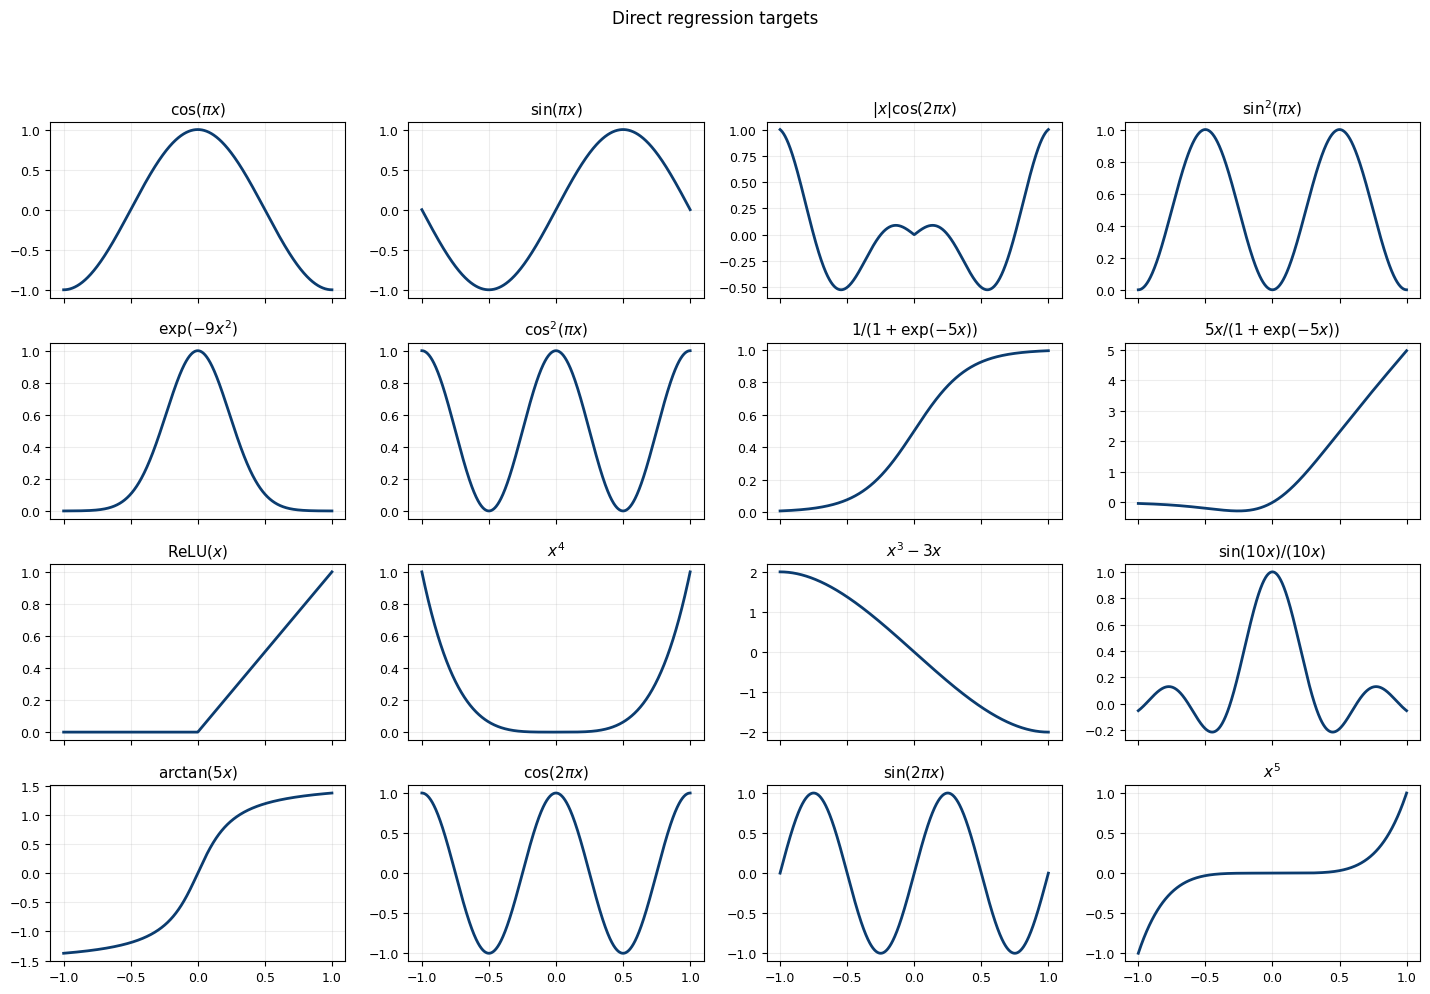

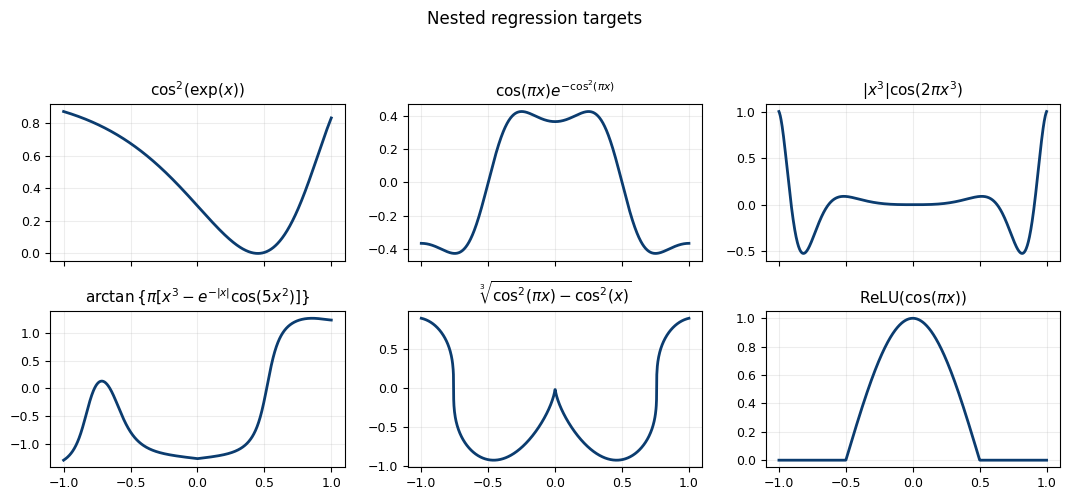

In [4]:
def plot_target_grid(tasks, title, columns=4):
    rows = math.ceil(len(tasks) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(3.6 * columns, 2.5 * rows),
        sharex=True,
    )
    axes = np.asarray(axes).reshape(-1)
    x = np.linspace(-1.0, 1.0, 1_000)
    for ax, task in zip(axes, tasks):
        ax.plot(x, function_1d(task, x), color=KAN_COLOUR, lw=2)
        ax.set_title(FUNCTION_LABELS[task])
        ax.grid(alpha=GRID_ALPHA)
    for ax in axes[len(tasks):]:
        ax.axis("off")
    fig.suptitle(title, y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig


direct_target_figure = plot_target_grid(
    ACTIVE_DIRECT_TASKS,
    "Direct regression targets",
)
plt.show()

nested_target_figure = plot_target_grid(
    ACTIVE_NESTED_TASKS,
    "Nested regression targets",
    columns=3,
)
plt.show()


## Hyperparameters

These are the `[1,1]`, `[1,1,1]` and MLP hyperparameters used in the notebook.

They can be thought of as a single synapse `[1,1]`, termed "shallow" in the code text, and two series connected synapses `[1,1,1]`, which additionally can be treated as a single "meta synapse" with a series interconnection but acting as a single one-dimensional synapse. The `[1,1,1]` is termed "deep" in the code text below.


In [5]:
SHALLOW_KAN_RECIPE = {
    "architecture_tag": "1_1",
    "SYNEs_per_synapse": 6,
    "beta1": 0.7641123523758361,
    "beta2": 0.8984447978390894,
    "scheduler": "cosine",
    "lr_min_frac": 0.05307889631241216,
    "step_gamma": 0.7644683659822252,
    "batch_size": 64,
    "grad_clip": 0.276306071255106,
    "init_style": "xavier",
    "init_dv_min": 1.1574255072306445,
    "init_dv_max": 1.4455486551060337,
    "span_jitter": 0.042374767971200565,
    "invert_probability": 0.6285223021139119,
    "pl_alpha": 1.5026334450676657,
    "pl_beta": 1.2783950050209487,
    "control_init_scale": 0.6048763508826048,
    "output_gain_scale": 50.0,
    "lr_gobo": 0.0011827968833113581,
    "lr_v": 0.0013958853237215636,
    "lr_s": 0.0012640715435287204,
    "evaluate_every": 10,
    "minimum_epochs": 100,
    "patience_evaluations": 20,
    "min_delta": 1e-8,
    "adam_eps": 1e-8,
}

DEEP_KAN_RECIPE = {
    "architecture_tag": "1_1_1",
    "SYNEs_per_synapse": 6,
    "beta1": 0.7866800350142098,
    "beta2": 0.8679820704764776,
    "scheduler": "cosine",
    "lr_min_frac": 0.11777654791892776,
    "step_gamma": 0.7036800450506023,
    "batch_size": 128,
    "grad_clip": 9.106258515494698,
    "init_style": "powerlaw",
    "init_dv_min": 0.88095383923597,
    "init_dv_max": 1.194830128710366,
    "span_jitter": 0.2023370771771321,
    "invert_probability": 0.48224625638921814,
    "pl_alpha": 0.06692553822963865,
    "pl_beta": 0.17636030115172524,
    "control_init_scale": 0.297454333548436,
    "output_gain_scale": 25.0,
    "lr_gobo": 0.002421028941287217,
    "lr_v": 0.0003072069864614243,
    "lr_s": 0.0010021366585754277,
    "evaluate_every": 10,
    "minimum_epochs": 100,
    "patience_evaluations": 20,
    "min_delta": 1e-8,
    "adam_eps": 1e-8,
}

MLP_RECIPE = {
    "beta1": 0.7883299220953616,
    "beta2": 0.9725326975918507,
    "scheduler": "cosine",
    "lr_min_frac": 0.11722103858403445,
    "step_gamma": 0.6538934117876128,
    "batch_size": 64,
    "grad_clip": 3.1905334214834458,
    "optimizer": "adamw",
    "weight_decay": 7.71714793548683e-08,
    "lr": 0.0015261511013669566,
    "evaluate_every": 10,
    "minimum_epochs": 100,
    "patience_evaluations": 20,
    "min_delta": 1e-8,
}

RELEASE_RECIPES = {
    "shallow_1_1": SHALLOW_KAN_RECIPE,
    "deep_1_1_1": DEEP_KAN_RECIPE,
    "relu_mlp": MLP_RECIPE,
}
(OUTPUT_ROOT / "fixed_release_recipes.json").write_text(
    json.dumps(RELEASE_RECIPES, indent=2), encoding="utf-8"
)

print(json.dumps(RELEASE_RECIPES, indent=2))

{
  "shallow_1_1": {
    "architecture_tag": "1_1",
    "SYNEs_per_synapse": 6,
    "beta1": 0.7641123523758361,
    "beta2": 0.8984447978390894,
    "scheduler": "cosine",
    "lr_min_frac": 0.05307889631241216,
    "step_gamma": 0.7644683659822252,
    "batch_size": 64,
    "grad_clip": 0.276306071255106,
    "init_style": "xavier",
    "init_dv_min": 1.1574255072306445,
    "init_dv_max": 1.4455486551060337,
    "span_jitter": 0.042374767971200565,
    "invert_probability": 0.6285223021139119,
    "pl_alpha": 1.5026334450676657,
    "pl_beta": 1.2783950050209487,
    "control_init_scale": 0.6048763508826048,
    "output_gain_scale": 50.0,
    "lr_gobo": 0.0011827968833113581,
    "lr_v": 0.0013958853237215636,
    "lr_s": 0.0012640715435287204,
    "evaluate_every": 10,
    "minimum_epochs": 100,
    "patience_evaluations": 20,
    "min_delta": 1e-08,
    "adam_eps": 1e-08
  },
  "deep_1_1_1": {
    "architecture_tag": "1_1_1",
    "SYNEs_per_synapse": 6,
    "beta1": 0.786680035014

## SYNE device digital twin

The loader accepts a saved `nn.Module` or a compatible MLP state dictionary. The SYNE device digital twin is converted to float32, placed in evaluation mode and frozen.


In [6]:
class RebuiltTwin(nn.Module):
    '''Small compatibility wrapper for a checkpoint containing only an MLP state_dict.'''

    def __init__(self, weights, biases):
        super().__init__()
        self.weights = nn.ParameterList(
            [nn.Parameter(w.clone(), requires_grad=False) for w in weights]
        )
        self.biases = nn.ParameterList(
            [nn.Parameter(b.clone(), requires_grad=False) for b in biases]
        )

    def forward(self, x):
        for layer, (weight, bias) in enumerate(zip(self.weights, self.biases)):
            x = F.linear(x, weight, bias)
            if layer + 1 < len(self.weights):
                x = F.relu(x)
        return x


def _natural_key(name: str):
    return [int(part) if part.isdigit() else part for part in re.split(r"(\d+)", name)]


def _strip_prefix(text: str, prefix: str) -> str:
    '''Python 3.8-compatible replacement for str.removeprefix().'''
    return text[len(prefix):] if text.startswith(prefix) else text


def _torch_load_compat(path: Path):
    # weights_only was added after older supported PyTorch releases.
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def load_frozen_twin(path: Path) -> nn.Module:
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f"Digital twin not found: {path}\n"
            "Place SYNE_device_digital_twin.pt beside the notebook, set TWIN_PATH, "
            "or define the SYNE_TWIN_PATH environment variable."
        )

    payload = _torch_load_compat(path)
    if isinstance(payload, nn.Module):
        twin = payload
    elif isinstance(payload, (list, tuple)) and payload and isinstance(payload[0], nn.Module):
        twin = payload[0]
    else:
        if isinstance(payload, dict):
            state = payload.get("model_state_dict", payload.get("state_dict", payload))
        else:
            state = None
        if not isinstance(state, dict):
            raise TypeError(f"Unsupported twin checkpoint payload: {type(payload)}")

        cleaned_state = {}
        for key, value in state.items():
            key = _strip_prefix(str(key), "module.")
            key = _strip_prefix(key, "model.")
            cleaned_state[key] = value

        weight_keys = sorted(
            [
                key for key, value in cleaned_state.items()
                if key.endswith("weight") and getattr(value, "ndim", 0) == 2
            ],
            key=_natural_key,
        )
        if not weight_keys:
            raise ValueError("No two-dimensional linear weights were found in the twin checkpoint")

        weights, biases = [], []
        for key in weight_keys:
            weight = cleaned_state[key].float()
            bias_key = key[:-6] + "bias"
            bias = cleaned_state.get(bias_key, torch.zeros(weight.shape[0])).float()
            weights.append(weight)
            biases.append(bias)
        twin = RebuiltTwin(weights, biases)

    twin = twin.to(DEVICE).float().eval()
    for parameter in twin.parameters():
        parameter.requires_grad_(False)

    print(f"Loaded and froze {path.name} ({type(twin).__name__})")
    return twin


TWIN = load_frozen_twin(TWIN_PATH)


Loaded and froze SYNE_device_digital_twin.pt (RebuiltTwin)


## Physical KAN

Each synapse sums `SYNEs_per_synapse` parallel SYNE responses. The trainable quantities are the signal ranges, control voltages, output gains and output biases.


In [7]:
ARCHITECTURES = {"1_1": [1, 1], "1_1_1": [1, 1, 1]}


class PhysicalKAN(nn.Module):
    '''Constant-control SYNE-KAN using the SYNE device digital twin.'''

    def __init__(self, twin, architecture, SYNEs_per_synapse, hp):
        super().__init__()
        self.twin = twin
        self.architecture = [int(value) for value in architecture]
        self.SYNEs_per_synapse = int(SYNEs_per_synapse)
        self.hp = dict(hp)
        self.squash_gain = 6.0
        self.output_gain_scale = float(hp["output_gain_scale"])
        self.twin_microbatch = int(hp.get("twin_microbatch", 262_144))

        for parameter in self.twin.parameters():
            parameter.requires_grad_(False)

        self.S_min = nn.ParameterList()
        self.S_max = nn.ParameterList()
        self.V = nn.ParameterList()
        self.G_o = nn.ParameterList()
        self.B_o = nn.ParameterList()

        for n_in, n_out in zip(self.architecture[:-1], self.architecture[1:]):
            shape = (n_in, n_out, self.SYNEs_per_synapse)
            self.S_min.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.S_max.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.V.append(nn.Parameter(torch.zeros(*shape, 2, device=DEVICE)))
            self.G_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))
            self.B_o.append(nn.Parameter(torch.zeros(shape, device=DEVICE)))

        self._initialise()

    def train(self, mode=True):
        super().train(mode)
        self.twin.eval()
        return self

    def squash_signal(self, raw):
        return 2.0 * torch.sigmoid(self.squash_gain * raw) - 1.0

    @staticmethod
    def squash_control(raw):
        return 2.0 * torch.sigmoid(raw) - 1.0

    def inverse_signal(self, value):
        probability = ((value + 1.0) * 0.5).clamp(1e-6, 1.0 - 1e-6)
        return torch.log(probability / (1.0 - probability)) / self.squash_gain

    def _initialise(self):
        with torch.no_grad():
            for layer, (n_in, n_out) in enumerate(
                zip(self.architecture[:-1], self.architecture[1:])
            ):
                shape = (n_in, n_out, self.SYNEs_per_synapse)
                count = int(np.prod(shape))
                dv_min = float(self.hp["init_dv_min"])
                dv_max = min(float(self.hp["init_dv_max"]), 1.96)

                widths = torch.linspace(dv_min, dv_max, count, device=DEVICE)
                step = (dv_max - dv_min) / max(count - 1, 1)
                jitter = float(self.hp["span_jitter"])
                widths += (torch.rand(count, device=DEVICE) - 0.5) * 2 * step * jitter
                widths = widths.clamp(dv_min, dv_max)
                widths = widths[torch.randperm(count, device=DEVICE)].reshape(shape)

                fan = float(n_in * self.SYNEs_per_synapse)
                if self.hp["init_style"] == "powerlaw":
                    contraction = max(
                        0.1,
                        min(1.0, fan ** (-float(self.hp["pl_beta"]))),
                    )
                    widths = dv_min + (widths - dv_min) * contraction

                inverted = (
                    torch.rand(shape, device=DEVICE)
                    < float(self.hp["invert_probability"])
                )
                low = -0.98 + 0.5 * widths
                high = 0.98 - 0.5 * widths
                centre = low + torch.rand(shape, device=DEVICE) * (high - low)
                centre = torch.where(inverted, torch.zeros_like(centre), centre)

                vmin = centre - 0.5 * widths
                vmax = centre + 0.5 * widths
                lower = torch.where(inverted, vmax, vmin)
                upper = torch.where(inverted, vmin, vmax)
                self.S_min[layer].copy_(self.inverse_signal(lower.clamp(-0.98, 0.98)))
                self.S_max[layer].copy_(self.inverse_signal(upper.clamp(-0.98, 0.98)))

                if self.hp["init_style"] == "powerlaw":
                    shrink = fan ** (-float(self.hp["pl_alpha"]))
                else:
                    shrink = 1.0
                limit = math.sqrt(6.0 / 4.0) * float(
                    self.hp["control_init_scale"]
                ) * shrink

                # Initialise both control voltages symmetrically.
                self.V[layer].uniform_(-limit, limit)
                self.G_o[layer].zero_()
                self.B_o[layer].zero_()

    def _twin_forward(self, flattened_inputs):
        chunks = []
        for start in range(0, len(flattened_inputs), self.twin_microbatch):
            chunks.append(
                self.twin(
                    flattened_inputs[start : start + self.twin_microbatch]
                ).reshape(-1)
            )
        return torch.cat(chunks, dim=0)

    def forward(self, inputs):
        activation = inputs
        for layer, (n_in, n_out) in enumerate(
            zip(self.architecture[:-1], self.architecture[1:])
        ):
            scalar = activation.unsqueeze(2).unsqueeze(3)
            minimum = self.squash_signal(self.S_min[layer])
            maximum = self.squash_signal(self.S_max[layer])

            signal = (
                0.5 * (maximum - minimum).unsqueeze(0) * scalar
                + 0.5 * (maximum + minimum).unsqueeze(0)
            ).unsqueeze(-1)
            controls = self.squash_control(self.V[layer]).unsqueeze(0)
            controls = controls.expand(len(activation), -1, -1, -1, -1)

            twin_inputs = torch.cat([signal, controls], dim=-1)
            twin_outputs = self._twin_forward(twin_inputs.reshape(-1, 3))
            twin_outputs = twin_outputs.reshape(
                len(activation), n_in, n_out, self.SYNEs_per_synapse
            )

            contribution = (
                self.output_gain_scale
                * self.G_o[layer].unsqueeze(0)
                * twin_outputs
            )
            contribution = contribution + self.B_o[layer].unsqueeze(0)
            activation = contribution.sum(dim=(1, 3))
        return activation

    def parameter_groups(self):
        '''Learning-rate groups for outputs, controls and signal ranges.'''
        ranges = list(self.S_min.parameters()) + list(self.S_max.parameters())
        controls = list(self.V.parameters())
        outputs = list(self.G_o.parameters()) + list(self.B_o.parameters())
        return [
            {
                "name": "gains_biases",
                "params": outputs,
                "lr": float(self.hp["lr_gobo"]),
                "weight_decay": 0.0,
            },
            {
                "name": "controls",
                "params": controls,
                "lr": float(self.hp["lr_v"]),
                "weight_decay": 0.0,
            },
            {
                "name": "ranges",
                "params": ranges,
                "lr": float(self.hp["lr_s"]),
                "weight_decay": 0.0,
            },
        ]

    def trainable_parameter_count(self):
        edges = sum(
            n_in * n_out
            for n_in, n_out in zip(self.architecture[:-1], self.architecture[1:])
        )
        receiving_neurons = sum(self.architecture[1:])
        return 5 * edges * self.SYNEs_per_synapse + receiving_neurons


## ReLU MLP baselines

The baseline models use ReLU hidden layers with Xavier-initialised weights and zero biases.


In [8]:
class ReLUMLP(nn.Module):
    def __init__(self, n_in: int, n_out: int, width: int, depth: int):
        super().__init__()
        dimensions = [n_in] + [int(width)] * int(depth) + [n_out]
        layers = []
        for index, (left, right) in enumerate(
            zip(dimensions[:-1], dimensions[1:])
        ):
            linear = nn.Linear(left, right)
            nn.init.xavier_uniform_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.append(linear)
            if index + 1 < len(dimensions) - 1:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.net(inputs)

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def mlp_parameter_count(width: int, depth: int) -> int:
    dimensions = [1] + [int(width)] * int(depth) + [1]
    return sum(
        left * right + right
        for left, right in zip(dimensions[:-1], dimensions[1:])
    )


count_rows = []
for architecture_tag in ["1_1", "1_1_1"]:
    architecture = ARCHITECTURES[architecture_tag]
    for SYNEs_per_synapse in PROFILE["SYNEs_per_synapse_values"]:
        hp = dict(
            SHALLOW_KAN_RECIPE if architecture_tag == "1_1" else DEEP_KAN_RECIPE,
            SYNEs_per_synapse=SYNEs_per_synapse,
        )
        model = PhysicalKAN(TWIN, architecture, SYNEs_per_synapse, hp)
        count_rows.append(
            {
                "model": f"KAN [{','.join(map(str, architecture))}], SYNEs/synapse={SYNEs_per_synapse}",
                "trainable_parameters": model.trainable_parameter_count(),
            }
        )
        del model

for depth, widths in PROFILE["mlp_widths_by_depth"].items():
    for width in widths:
        count = mlp_parameter_count(width, depth)
        count_rows.append(
            {
                "model": f"MLP, L={depth}, H={width}",
                "trainable_parameters": count,
            }
        )

PARAMETER_COUNTS = pd.DataFrame(count_rows)
PARAMETER_COUNTS

,model,trainable_parameters
0,"KAN [1,1], SYNEs/synapse=2",11
1,"KAN [1,1], SYNEs/synapse=4",21
2,"KAN [1,1], SYNEs/synapse=6",31
3,"KAN [1,1], SYNEs/synapse=8",41
4,"KAN [1,1], SYNEs/synapse=10",51
5,"KAN [1,1], SYNEs/synapse=12",61
6,"KAN [1,1,1], SYNEs/synapse=2",22
7,"KAN [1,1,1], SYNEs/synapse=4",42
8,"KAN [1,1,1], SYNEs/synapse=6",62
9,"KAN [1,1,1], SYNEs/synapse=8",82


## Training

The KAN uses separate learning rates for output coefficients, control voltages and signal ranges. The MLP uses its own optimiser settings. Validation is checked every ten epochs, and the best checkpoint is used for the test MSE.


In [9]:
def compact_state(model: nn.Module) -> dict[str, torch.Tensor]:
    trainable = {name for name, parameter in model.named_parameters() if parameter.requires_grad}
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
        if key in trainable
    }


def restore_compact_state(model: nn.Module, state: dict[str, torch.Tensor]) -> None:
    current = model.state_dict()
    current.update({key: value.to(current[key].device) for key, value in state.items()})
    model.load_state_dict(current, strict=True)


def make_optimizer(model: nn.Module, hp: dict):
    if isinstance(model, PhysicalKAN):
        return torch.optim.Adam(
            model.parameter_groups(),
            betas=(float(hp["beta1"]), float(hp["beta2"])),
            eps=float(hp.get("adam_eps", 1e-8)),
        )

    optimizer_class = (
        torch.optim.AdamW if hp["optimizer"] == "adamw" else torch.optim.Adam
    )
    return optimizer_class(
        model.parameters(),
        lr=float(hp["lr"]),
        betas=(float(hp["beta1"]), float(hp["beta2"])),
        eps=1e-8,
        weight_decay=float(hp["weight_decay"]),
    )


def make_scheduler(optimizer, hp: dict, max_epochs: int):
    if hp["scheduler"] == "cosine":
        minimum = float(hp["lr_min_frac"])

        def cosine_multiplier(epoch):
            progress = min(max(epoch, 0), max_epochs - 1) / float(
                max(max_epochs - 1, 1)
            )
            return minimum + 0.5 * (1.0 - minimum) * (
                1.0 + math.cos(math.pi * progress)
            )

        return torch.optim.lr_scheduler.LambdaLR(
            optimizer, lr_lambda=cosine_multiplier
        )

    if hp["scheduler"] == "step":
        return torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=max(20, max_epochs // 8),
            gamma=float(hp["step_gamma"]),
        )
    return None


@torch.no_grad()
def predict(model: nn.Module, inputs: torch.Tensor, chunk_size: int = 8_192):
    model.eval()
    outputs = []
    for start in range(0, len(inputs), chunk_size):
        outputs.append(
            model(inputs[start : start + chunk_size].to(DEVICE)).detach().cpu()
        )
    return torch.cat(outputs)


def train_one(model, split, hp, max_epochs: int, seed: int, verbose=False):
    seed_everything(seed)
    model = model.to(DEVICE)
    optimizer = make_optimizer(model, hp)
    scheduler = make_scheduler(optimizer, hp, max_epochs)
    loss_function = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(split["x_train"], split["y_train"]),
        batch_size=int(hp["batch_size"]),
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
        pin_memory=torch.cuda.is_available(),
    )

    best_loss = float("inf")
    best_epoch = 0
    best_state = None
    evaluations_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            prediction = model(inputs)
            loss = loss_function(prediction.reshape_as(targets), targets)
            if not bool(torch.isfinite(loss)):
                raise FloatingPointError(f"Non-finite training loss at epoch {epoch}")
            loss.backward()
            if float(hp["grad_clip"]) > 0:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    float(hp["grad_clip"]),
                )
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        should_evaluate = (
            epoch == 1
            or epoch % int(hp["evaluate_every"]) == 0
            or epoch == max_epochs
        )
        if not should_evaluate:
            continue

        validation_prediction = predict(model, split["x_val"])
        validation_loss = float(
            loss_function(
                validation_prediction.reshape_as(split["y_val"]),
                split["y_val"],
            ).item()
        )
        history.append((epoch, validation_loss))

        if validation_loss < best_loss - float(hp["min_delta"]):
            best_loss = validation_loss
            best_epoch = epoch
            best_state = compact_state(model)
            evaluations_without_improvement = 0
        else:
            evaluations_without_improvement += 1

        if verbose:
            print(
                f"epoch={epoch:4d}  val={validation_loss:.6g}  "
                f"best={best_loss:.6g}@{best_epoch}"
            )

        if (
            epoch >= int(hp["minimum_epochs"])
            and evaluations_without_improvement
            >= int(hp["patience_evaluations"])
        ):
            break

    if best_state is None:
        raise FloatingPointError("Training ended without a finite validation checkpoint")
    restore_compact_state(model, best_state)
    return model, {
        "best_validation_mse": best_loss,
        "best_epoch": best_epoch,
        "history": history,
    }

## Result logging

Each run ID contains the model recipe, architecture, seed and epoch budget. Completed rows are stored in `runs.csv` and skipped when the notebook is resumed.


In [10]:
RESULTS_PATH = OUTPUT_ROOT / "runs.csv"


def recipe_signature(hp: dict) -> str:
    payload = json.dumps(hp, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:12]


def prediction_path(model_family, suite, task, configuration, seed, signature):
    filename = f"{model_family}_{suite}_{task}_{configuration}_seed{seed}_{signature}.npz"
    return PREDICTION_ROOT / filename.replace("/", "_")


def load_results() -> pd.DataFrame:
    if not RESULTS_PATH.exists():
        return pd.DataFrame()
    frame = pd.read_csv(RESULTS_PATH)
    if "run_id" not in frame:
        raise ValueError(f"Existing results file has no run_id column: {RESULTS_PATH}")
    return frame.drop_duplicates("run_id", keep="last").reset_index(drop=True)


def save_results(frame: pd.DataFrame) -> None:
    temporary = RESULTS_PATH.with_suffix(".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(RESULTS_PATH)


RESULTS = load_results()
COMPLETED_RUN_IDS = set(RESULTS["run_id"].astype(str)) if len(RESULTS) else set()


def run_and_record(
    *,
    model_family: str,
    suite: str,
    task: str,
    seed: int,
    configuration: str,
    architecture: str,
    hp: dict,
    model_factory,
    SYNEs_per_synapse=None,
    depth=None,
    width=None,
    reported_parameters=None,
    save_prediction=False,
) -> bool:
    global RESULTS

    signature = recipe_signature(hp)
    run_id = "|".join(
        map(
            str,
            [
                model_family,
                suite,
                task,
                seed,
                configuration,
                signature,
                PROFILE["max_epochs"],
            ],
        )
    )
    if run_id in COMPLETED_RUN_IDS:
        return False

    run_seed = stable_seed("release_1d", run_id)
    seed_everything(run_seed)  # seed before constructing the model
    model = model_factory()
    split = make_split(task, seed)
    model, training = train_one(
        model,
        split,
        hp,
        max_epochs=int(PROFILE["max_epochs"]),
        seed=run_seed,
    )

    test_prediction = predict(model, split["x_test"])
    test_mse = float(
        F.mse_loss(
            test_prediction.reshape_as(split["y_test"]), split["y_test"]
        ).item()
    )

    if reported_parameters is None:
        reported_parameters = model.trainable_parameter_count()

    row = {
        "run_id": run_id,
        "recipe_signature": signature,
        "profile": RUN_PROFILE,
        "model_family": model_family,
        "suite": suite,
        "task": task,
        "seed": int(seed),
        "training_seed": int(run_seed),
        "configuration": configuration,
        "architecture": architecture,
        "SYNEs_per_synapse": SYNEs_per_synapse,
        "depth": depth,
        "width": width,
        "trainable_parameters": int(reported_parameters),
        "best_validation_mse": float(training["best_validation_mse"]),
        "test_mse": test_mse,
        "best_epoch": int(training["best_epoch"]),
        "max_epochs": int(PROFILE["max_epochs"]),
    }

    if save_prediction:
        np.savez_compressed(
            prediction_path(
                model_family, suite, task, configuration, seed, signature
            ),
            x=split["x_test"].numpy().reshape(-1),
            target=split["y_test"].numpy().reshape(-1),
            prediction=test_prediction.numpy().reshape(-1),
        )

    RESULTS = pd.concat([RESULTS, pd.DataFrame([row])], ignore_index=True)
    COMPLETED_RUN_IDS.add(run_id)
    save_results(RESULTS)
    print(
        f"{model_family:3s} | {configuration:12s} | {task:38s} | "
        f"seed {seed} | test MSE {test_mse:.4e}"
    )
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return True

## Run the physical KAN sweeps

`[1,1]` is evaluated on the direct functions. `[1,1,1]` is evaluated on the direct and nested functions. The paper profile uses `SYNEs_per_synapse = 2, 4, 6, 8, 10, 12`.


In [11]:
REPRESENTATIVE_SEED = PROFILE["seeds"][0]


def run_kan_sweep(architecture_tag, tasks_by_suite, SYNEs_per_synapse_values, base_recipe):
    architecture = ARCHITECTURES[architecture_tag]
    architecture_label = "[" + ",".join(map(str, architecture)) + "]"

    for SYNEs_per_synapse in SYNEs_per_synapse_values:
        hp = dict(
            base_recipe,
            architecture_tag=architecture_tag,
            SYNEs_per_synapse=int(SYNEs_per_synapse),
        )
        probe = PhysicalKAN(TWIN, architecture, SYNEs_per_synapse, hp)
        reported_count = probe.trainable_parameter_count()
        del probe

        configuration = f"{architecture_tag}_SYNEs{SYNEs_per_synapse}"
        for suite, tasks in tasks_by_suite.items():
            for task in tasks:
                for seed in PROFILE["seeds"]:
                    run_and_record(
                        model_family="KAN",
                        suite=suite,
                        task=task,
                        seed=seed,
                        configuration=configuration,
                        architecture=architecture_label,
                        hp=hp,
                        model_factory=lambda architecture=architecture, SYNEs_per_synapse=SYNEs_per_synapse, hp=hp: PhysicalKAN(
                            TWIN, architecture, SYNEs_per_synapse, hp
                        ),
                        SYNEs_per_synapse=SYNEs_per_synapse,
                        reported_parameters=reported_count,
                        save_prediction=(
                            SYNEs_per_synapse == 6 and seed == REPRESENTATIVE_SEED
                        ),
                    )


if RUN_SHALLOW_KAN:
    run_kan_sweep(
        "1_1",
        {"direct": ACTIVE_DIRECT_TASKS},
        PROFILE["SYNEs_per_synapse_values"],
        SHALLOW_KAN_RECIPE,
    )

if RUN_DEEP_KAN:
    run_kan_sweep(
        "1_1_1",
        {"direct": ACTIVE_DIRECT_TASKS, "nested": ACTIVE_NESTED_TASKS},
        PROFILE["SYNEs_per_synapse_values"],
        DEEP_KAN_RECIPE,
    )

print(f"Stored {len(RESULTS)} rows in {RESULTS_PATH}")

Stored 856 rows in C:\Users\Jack Gartside\KAN_SciAdv_Response\NewCodes\ReleaseFinessing\NewNew\results_1d_release_v2\paper\runs.csv


## Run the ReLU MLP sweep



In [ ]:
def run_mlp_sweep(tasks_by_suite, widths_by_depth):
    representative_configurations = {"L1_H10", "L1_H20", "L2_H5", "L3_H5"}

    for depth, widths in widths_by_depth.items():
        for width in widths:
            hp = dict(MLP_RECIPE, depth=int(depth), width=int(width))
            configuration = f"L{depth}_H{width}"
            count = mlp_parameter_count(width, depth)

            for suite, tasks in tasks_by_suite.items():
                for task in tasks:
                    for seed in PROFILE["seeds"]:
                        run_and_record(
                            model_family="MLP",
                            suite=suite,
                            task=task,
                            seed=seed,
                            configuration=configuration,
                            architecture=f"ReLU MLP, {depth} hidden layer(s)",
                            hp=hp,
                            model_factory=lambda width=width, depth=depth: ReLUMLP(
                                1, 1, width, depth
                            ),
                            depth=depth,
                            width=width,
                            reported_parameters=count,
                            save_prediction=(
                                configuration in representative_configurations
                                and seed == REPRESENTATIVE_SEED
                            ),
                        )


if RUN_MLP_BASELINES:
    run_mlp_sweep(
        {"direct": ACTIVE_DIRECT_TASKS, "nested": ACTIVE_NESTED_TASKS},
        PROFILE["mlp_widths_by_depth"],
    )

print(f"Stored {len(RESULTS)} rows in {RESULTS_PATH}")

MLP | L1_H50       | cos_2pi                                | seed 505 | test MSE 2.5226e-03
MLP | L1_H50       | cos_2pi                                | seed 606 | test MSE 2.6037e-03
MLP | L1_H50       | sin_2pi                                | seed 404 | test MSE 1.2117e-01
MLP | L1_H50       | sin_2pi                                | seed 505 | test MSE 1.2199e-01
MLP | L1_H50       | sin_2pi                                | seed 606 | test MSE 1.4052e-01
MLP | L1_H50       | x5                                     | seed 404 | test MSE 9.0165e-07
MLP | L1_H50       | x5                                     | seed 505 | test MSE 4.7686e-07
MLP | L1_H50       | x5                                     | seed 606 | test MSE 6.4545e-07
MLP | L1_H50       | nested_cos_exp_sq                      | seed 404 | test MSE 5.5398e-07
MLP | L1_H50       | nested_cos_exp_sq                      | seed 505 | test MSE 6.3119e-07
MLP | L1_H50       | nested_cos_exp_sq                      | seed 606

## Results and scaling plots

MSE is combined with a geometric mean over seeds for each function, then across functions. Direct and nested tasks are plotted separately.


In [ ]:
RESULTS = load_results()
if RESULTS.empty:
    raise RuntimeError("No run data found. Run a KAN or MLP sweep first.")


GROUP_COLUMNS = [
    "model_family",
    "suite",
    "configuration",
    "recipe_signature",
    "architecture",
    "SYNEs_per_synapse",
    "depth",
    "width",
    "trainable_parameters",
]

function_summary = (
    RESULTS.groupby(GROUP_COLUMNS + ["task"], dropna=False)
    .agg(
        repeat_geometric_test_mse=("test_mse", geometric_mean),
        repeat_arithmetic_test_mse=("test_mse", "mean"),
        completed_repeats=("test_mse", "size"),
    )
    .reset_index()
)

configuration_summary = (
    function_summary.groupby(GROUP_COLUMNS, dropna=False)
    .agg(
        geometric_test_mse=("repeat_geometric_test_mse", geometric_mean),
        arithmetic_test_mse=("repeat_arithmetic_test_mse", "mean"),
        completed_functions=("task", "nunique"),
        minimum_repeats=("completed_repeats", "min"),
    )
    .reset_index()
    .sort_values(["suite", "model_family", "trainable_parameters"])
)

function_summary.to_csv(OUTPUT_ROOT / "summary_by_function.csv", index=False)
configuration_summary.to_csv(
    OUTPUT_ROOT / "summary_by_configuration.csv", index=False
)
configuration_summary

In [ ]:
def make_scaling_plot(configuration_summary, function_summary):
    direct_tasks = [task for task in SI_DIRECT_TASKS if task in ACTIVE_DIRECT_TASKS]
    nested_tasks = [task for task in NESTED_TASKS if task in ACTIVE_NESTED_TASKS]

    selected = pd.concat(
        [
            function_summary[
                (function_summary["suite"] == "direct")
                & function_summary["task"].isin(direct_tasks)
            ].assign(analysis_suite="direct_si13"),
            function_summary[
                (function_summary["suite"] == "nested")
                & function_summary["task"].isin(nested_tasks)
            ].assign(analysis_suite="nested_fig2c"),
        ],
        ignore_index=True,
    )

    plot_summary = (
        selected.groupby(GROUP_COLUMNS + ["analysis_suite"], dropna=False)
        .agg(
            geometric_test_mse=("repeat_geometric_test_mse", geometric_mean),
            completed_functions=("task", "nunique"),
            minimum_repeats=("completed_repeats", "min"),
        )
        .reset_index()
    )
    plot_summary.to_csv(OUTPUT_ROOT / "paper_matched_scaling_summary.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
    kan_colours = {"[1,1]": "#1976b9", "[1,1,1]": KAN_COLOUR}
    markers = {1: "^", 2: "s", 3: "D"}

    for ax, suite, title in zip(
        axes,
        ["direct_si13", "nested_fig2c"],
        ["Direct functions", "Nested functions"],
    ):
        subset = plot_summary[plot_summary["analysis_suite"] == suite]

        for architecture in ["[1,1]", "[1,1,1]"]:
            kan = subset[
                (subset["model_family"] == "KAN")
                & (subset["architecture"] == architecture)
            ].sort_values("trainable_parameters")
            if len(kan):
                ax.plot(
                    kan["trainable_parameters"],
                    kan["geometric_test_mse"],
                    "o-",
                    color=kan_colours[architecture],
                    lw=2,
                    label=f"Physical KAN {architecture}",
                )

        for depth in sorted(PROFILE["mlp_widths_by_depth"]):
            mlp = subset[
                (subset["model_family"] == "MLP")
                & (subset["depth"] == depth)
            ].sort_values("trainable_parameters")
            if len(mlp):
                ax.plot(
                    mlp["trainable_parameters"],
                    mlp["geometric_test_mse"],
                    marker=markers[depth],
                    ls="--",
                    color=MLP_COLOURS[depth],
                    lw=1.7,
                    label=f"MLP, {depth} hidden layer{'s' if depth > 1 else ''}",
                )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Trainable parameters")
        ax.set_ylabel("Geometric mean test MSE")
        ax.set_title(title)
        ax.grid(alpha=GRID_ALPHA, which="both")

    handles, labels = unique_legend_items(axes)
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.91),
        ncol=3,
        frameon=False,
        columnspacing=1.2,
    )
    fig.suptitle("1D regression parameter scaling", y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.83))
    save_figure(fig, OUTPUT_ROOT / "parameter_performance_scaling.png")
    return fig, plot_summary


scaling_figure, paper_scaling_summary = make_scaling_plot(
    configuration_summary,
    function_summary,
)
plt.show()
paper_scaling_summary


## Representative fits

These figures show the target functions and saved predictions for selected KAN and MLP configurations.


In [ ]:
def find_prediction(model_family, suite, task, configuration, seed):
    matches = sorted(
        PREDICTION_ROOT.glob(
            f"{model_family}_{suite}_{task}_{configuration}_seed{seed}_*.npz"
        )
    )
    return matches[-1] if matches else None


def plot_reconstructions(tasks, suite, kan_configuration, mlp_configuration, columns=3):
    rows = math.ceil(len(tasks) / columns)
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(4.2 * columns, 2.8 * rows),
        sharex=True,
    )
    axes = np.asarray(axes).reshape(-1)

    for ax, task in zip(axes, tasks):
        kan_path = find_prediction(
            "KAN", suite, task, kan_configuration, REPRESENTATIVE_SEED
        )
        mlp_path = find_prediction(
            "MLP", suite, task, mlp_configuration, REPRESENTATIVE_SEED
        )
        available_path = kan_path or mlp_path
        if available_path is None:
            ax.text(0.5, 0.5, "Prediction unavailable", ha="center", va="center")
            ax.set_axis_off()
            continue

        reference = np.load(available_path)
        ax.plot(
            reference["x"],
            reference["target"],
            color=TARGET_COLOUR,
            lw=2,
            label="Target",
        )
        if kan_path is not None:
            kan = np.load(kan_path)
            ax.plot(
                kan["x"],
                kan["prediction"],
                color=KAN_COLOUR,
                lw=1.6,
                label="Physical KAN",
            )
        if mlp_path is not None:
            mlp = np.load(mlp_path)
            ax.plot(
                mlp["x"],
                mlp["prediction"],
                color=MLP_COLOURS[1],
                lw=1.4,
                label="MLP",
            )
        ax.set_title(FUNCTION_LABELS[task])
        ax.grid(alpha=GRID_ALPHA)

    for ax in axes[len(tasks):]:
        ax.axis("off")

    handles, labels = unique_legend_items(axes)
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=3,
            frameon=False,
        )
    fig.tight_layout(rect=(0, 0, 1, 0.91))
    return fig


direct_figure = plot_reconstructions(
    ACTIVE_DIRECT_TASKS,
    suite="direct",
    kan_configuration="1_1_SYNEs6",
    mlp_configuration="L1_H10",
    columns=3,
)
save_figure(direct_figure, OUTPUT_ROOT / "direct_reconstructions.png")
plt.show()

nested_figure = plot_reconstructions(
    ACTIVE_NESTED_TASKS,
    suite="nested",
    kan_configuration="1_1_1_SYNEs6",
    mlp_configuration="L1_H20",
    columns=3,
)
save_figure(nested_figure, OUTPUT_ROOT / "nested_reconstructions.png")
plt.show()


## Output files

Each profile writes:

- `runs.csv`
- `summary_by_function.csv`
- `summary_by_configuration.csv`
- `paper_matched_scaling_summary.csv`
- `fixed_release_recipes.json`
- `predictions/*.npz`
- parameter-scaling and fitted-function PNG files
